In [1]:
import logging
import os
from pathlib import Path
import re

from IPython.display import display
from matplotlib.figure import Figure
import matplotlib.pyplot as plt
import pandas as pd

from kibad_llm.config import PROJ_ROOT
from kibad_llm.utils.job_return import load_runs, mixed_group_by

# set INFO log level to show loaded file paths
logging.basicConfig(level=logging.INFO)

# swith to project root to use same paths as in commands
os.chdir(PROJ_ROOT)
# set wider column width for displaying pandas data frames
pd.set_option("max_colwidth", 400)
# show all columns
pd.set_option("display.max_columns", None)

logger = logging.getLogger(__name__)

# Some good defaults

BASE_LOG_DIR = Path("data/prediction_results/logs")

# don't load this data to declutter the data frames
EXCLUDE_KEYS = [
    "prediction.job_return_value.output_file",
    "overrides.paths.save_dir",
    "overrides.pdf_directory",
]
# set any missing (default) values as column name -> value
FILL_NA = {}
# passed when plotting metrics and errors
FIGSIZE = (10, 10)
# if necessary, provide one or multiple subdirs
SUBDIR = "evaluate"
# optional prefix for plot file names
FILE_NAME_PREFIX = ""

2026-02-03 11:38:58.352 | INFO     | kibad_llm.config:<module>:11 - PROJ_ROOT path is: /home/arbi01/projects/kibad-llm


In [2]:
# POST YOUR "NOTEBOOK PARAMETERS" FROM THE EXPERIMENT README HERE

NAME = "88_faktencheck_core_gpt5_baseline"

# used to group the data
INDEX_COLUMNS = ["prediction.overrides.extractor/llm"]
PLOT_KWARGS = {
    # can be either "metric" or one of the INDEX_COLUMNS (or multiple of them)
    "xgroup": "prediction.overrides.extractor/llm",
    # add any more arguments passed to pd.DataFrame.plot
}

# Load Run Data

In [3]:
all_df = pd.DataFrame.from_records(
    load_runs(
        directory=BASE_LOG_DIR / NAME,
        subdir=SUBDIR,
        exclude_keys=EXCLUDE_KEYS,
    )
).fillna(FILL_NA)
# display(all_df)
# replace individual missing values with zero counts
errors_df = (
    all_df[all_df["overrides.experiment/evaluate"] == "prediction_errors"]
    .dropna(axis="columns", how="all")
    .fillna(0)
)
# display(errors_df)
metrics_df = all_df[all_df["overrides.experiment/evaluate"] != "prediction_errors"].dropna(
    axis="columns", how="all"
)
metrics_df

INFO:kibad_llm.utils.job_return:Loading job_return_value.json from 6 files from the following parent directories (directory: data/prediction_results/logs/88_faktencheck_core_gpt5_baseline, subdir: ['evaluate']):
data/prediction_results/logs/88_faktencheck_core_gpt5_baseline/evaluate/multiruns/2026-02-01_18-01-52
data/prediction_results/logs/88_faktencheck_core_gpt5_baseline/evaluate/multiruns/2026-02-01_18-07-22


,biodiversity_level.precision,biodiversity_level.recall,biodiversity_level.f1,biodiversity_level.support,ecosystem_type.term.precision,ecosystem_type.term.recall,ecosystem_type.term.f1,ecosystem_type.term.support,habitat.precision,habitat.recall,habitat.f1,habitat.support,taxa.german_name.precision,taxa.german_name.recall,taxa.german_name.f1,taxa.german_name.support,taxa.scientific_name.precision,taxa.scientific_name.recall,taxa.scientific_name.f1,taxa.scientific_name.support,taxa.species_group.precision,taxa.species_group.recall,taxa.species_group.f1,taxa.species_group.support,AVG.precision,AVG.recall,AVG.f1,AVG.support,ALL.precision,ALL.recall,ALL.f1,ALL.support,prediction.job_return_value.output_file_absolute,prediction.job_return_value.time_pdf_conversion,prediction.job_return_value.time_extraction,prediction.job_return_value.commit_hash,prediction.job_return_value.branch,prediction.job_return_value.is_dirty,prediction.overrides.name,prediction.overrides.experiment/predict,prediction.overrides.pdf_directory,prediction.overrides.extractor.return_reasoning,prediction.overrides.extractor/llm,prediction.overrides.seed,overrides.dataset.predictions.log,overrides.name,overrides.experiment/evaluate,overrides.prediction_logs
0,0.347826,0.477612,0.402516,67.0,0.227848,0.679245,0.341232,53.0,0.653061,0.695652,0.673684,138.0,0.362069,0.181818,0.242075,231.0,0.344371,0.263959,0.298851,197.0,0.373418,0.556604,0.446970,106.0,0.384765,0.475815,0.400888,132.0,0.385645,0.400253,0.392813,792.0,/netscratch/binder/projects/kibad-llm/predictions/88_faktencheck_core_gpt5_baseline/2026-01-31_16-22-31/2026-01-31_16-22-31_957220/predictions.jsonl,0.036147,8128.767694,dd1413a20fc344dbbb95a79b18a4ab5c625cd3c5,run-script/parametrize-num-gpus,False,88_faktencheck_core_gpt5_baseline,faktencheck_core_fields_schema_with_evidence,/ds/text/kiba-d/dev-set-100,True,gpt_5,42,logs/88_faktencheck_core_gpt5_baseline/predict/multiruns/2026-01-31_16-22-31/0,88_faktencheck_core_gpt5_baseline,faktencheck_core_f1_micro_flat,logs/88_faktencheck_core_gpt5_baseline/predict
1,0.287129,0.432836,0.345238,67.0,0.250000,0.716981,0.370732,53.0,0.659722,0.688406,0.673759,138.0,0.336066,0.177489,0.232295,231.0,0.312500,0.304569,0.308483,197.0,0.426667,0.603774,0.500000,106.0,0.378681,0.487342,0.405084,132.0,0.379791,0.412879,0.395644,792.0,/netscratch/binder/projects/kibad-llm/predictions/88_faktencheck_core_gpt5_baseline/2026-01-31_16-22-31/2026-01-31_18-38-49_281164/predictions.jsonl,0.004648,6390.365084,dd1413a20fc344dbbb95a79b18a4ab5c625cd3c5,run-script/parametrize-num-gpus,False,88_faktencheck_core_gpt5_baseline,faktencheck_core_fields_schema_with_evidence,/ds/text/kiba-d/dev-set-100,True,gpt_5,1337,logs/88_faktencheck_core_gpt5_baseline/predict/multiruns/2026-01-31_16-22-31/1,88_faktencheck_core_gpt5_baseline,faktencheck_core_f1_micro_flat,logs/88_faktencheck_core_gpt5_baseline/predict
2,0.318182,0.417910,0.361290,67.0,0.233333,0.660377,0.344828,53.0,0.680272,0.724638,0.701754,138.0,0.361111,0.112554,0.171617,231.0,0.304054,0.228426,0.260870,197.0,0.386503,0.594340,0.468401,106.0,0.380576,0.456374,0.384793,132.0,0.386719,0.375000,0.380769,792.0,/netscratch/binder/projects/kibad-llm/predictions/88_faktencheck_core_gpt5_baseline/2026-01-31_16-22-31/2026-01-31_20-25-20_287885/predictions.jsonl,0.002904,6135.298248,dd1413a20fc344dbbb95a79b18a4ab5c625cd3c5,run-script/parametrize-num-gpus,False,88_faktencheck_core_gpt5_baseline,faktencheck_core_fields_schema_with_evidence,/ds/text/kiba-d/dev-set-100,True,gpt_5,7331,logs/88_faktencheck_core_gpt5_baseline/predict/multiruns/2026-01-31_16-22-31/2,88_faktencheck_core_gpt5_baseline,faktencheck_core_f1_micro_flat,logs/88_faktencheck_core_gpt5_baseline/predict


In [4]:
# loading "old" eval data (from before https://github.com/DFKI-NLP/kibad-llm/pull/337), requires METRICS_DIR_PATTERN and ERRORS_DIR_PATTERN
#
# from kibad_llm.utils.job_return import load
#
# errors_df = (
#     pd.DataFrame.from_records(
#         load(
#             directory=BASE_LOG_DIR / NAME,
#             subdir_pattern=ERRORS_DIR_PATTERN,
#             strip_id_keys=True,
#             flatten=True,
#             exclude_keys=EXCLUDE_KEYS,
#         )
#     )
#     .fillna(FILL_NA)
#     .fillna(0)
# )
# # display(errors_df)
#
# metrics_df = pd.DataFrame.from_records(
#     load(
#         directory=BASE_LOG_DIR / NAME,
#         subdir_pattern=METRICS_DIR_PATTERN,
#         strip_id_keys=True,
#         flatten=True,
#         exclude_keys=EXCLUDE_KEYS,
#     )
# ).fillna(FILL_NA)
# metrics_df

In [5]:
# show some grouping result
cols = ["ALL.precision", "ALL.recall", "ALL.f1"]
mixed_group_by(metrics_df[cols + INDEX_COLUMNS], by=INDEX_COLUMNS, columns_name="metric")

metric,ALL.precision,ALL.recall,ALL.f1
prediction.overrides.extractor/llm,,,
gpt_5,0.384051,0.396044,0.389742


In [6]:
def display_verbose(data: pd.DataFrame | None, verbose: bool, msg: str) -> None:
    if verbose and data is not None:
        logger.info(msg)
        display(data)


def get_grouped_y_and_yerr(
    data: pd.DataFrame,
    name: str,
    group_by: str | list[str],
    include_cols_regex: str | None = None,
    with_std_as_err: bool = True,
    verbose: bool = False,
):
    """Group and aggregate selected metric columns and optionally compute per-group error bars.

    This helper selects all columns whose name matches `include_cols_regex` (plus the grouping
    columns), groups the data by `group_by`, and computes the mean per group. If grouping
    reduces the number of rows (i.e., at least one group has multiple items) and
    `with_std_as_err` is enabled, it also computes the per-group standard deviation as an
    error estimate.

    Args:
        data: Input dataframe containing grouping columns and metric columns.
        name: Column name label used by `mixed_group_by` for the aggregated value column(s).
        group_by: Column name or list of column names to group by. A string is treated as a
            single grouping column.
        include_cols_regex: Regular expression used to select metric columns from `data.columns`.
            All matching columns are aggregated. If None, use all numeric columns.
        with_std_as_err: If True, compute standard deviation per group as `yerr` when grouping
            actually aggregates multiple rows. If False, `yerr` is always None.
        verbose: If True, log and display intermediate grouped DataFrames.

    Returns:
        A tuple `(y, yerr)` where:
            - `y` is the grouped mean DataFrame indexed by `group_by`.
            - `yerr` is the grouped standard deviation DataFrame (same shape/index as `y`)
              or None if not computed.
    """

    if isinstance(group_by, str):
        group_by = [group_by]

    if include_cols_regex is not None:
        cols = [col for col in data.columns if re.search(include_cols_regex, col)] + group_by
    else:
        cols = list(data.select_dtypes(include="number").columns) + group_by
    logger.info(f"use columns (name={name}): {cols}")

    # create grouped dataframe with mean (and std), indexed by 'by' columns
    y = mixed_group_by(data[cols], by=group_by, numeric_agg_func="mean", columns_name=name)
    display_verbose(data=y, msg=f"grouped data (by={group_by})):", verbose=verbose)
    # only calculate stddev when grouping reduced the number of rows
    if with_std_as_err and len(y) < len(data):
        yerr = mixed_group_by(
            data[cols], by=group_by, numeric_agg_func="std", columns_name=name
        ).fillna(0.0)
        display_verbose(data=yerr, msg=f"grouped stddev data (by={group_by}):", verbose=verbose)
    else:
        yerr = None

    return y, yerr


def plot(
    data: pd.DataFrame,
    index_column: str | list[str],
    include_cols_regex: str | None = None,
    create_subplot_for_each: str | list[str] | None = None,
    xgroup: str | list[str] | None = None,
    with_std_as_err: bool = True,
    name: str = "metric",
    figsize: tuple[int, int] = (15, 15),
    subplot_columns: int | None = None,
    subplot_rows: int | None = None,
    shorten_labels: bool = True,
    legend_kwargs: dict | None = None,
    verbose: bool = False,
    **plot_kwargs,
) -> Figure:
    """Plot grouped metric means as bar charts, optionally split into subplots and/or grouped bars.

    The function aggregates `data` by `index_column` (mean over all selected metric columns) and
    creates bar plots from the aggregated values. Metric columns are either selected via
    `include_cols_regex` or, if it is None, taken as all numeric columns. If `with_std_as_err`
    is enabled and the grouping reduces the number of rows, per-group standard deviations are
    computed and shown as error bars.

    Subplots are controlled via `create_subplot_for_each`: when provided, the aggregated result is
    reshaped so that each level listed there becomes a separate subplot. Within each subplot, bars
    can be further grouped by unstacking `xgroup`.

    Args:
        data: Input dataframe containing grouping columns and metric columns.
        index_column: Column name or list of column names to group by (x-axis categories). A list
            produces a MultiIndex grouping.
        include_cols_regex: Regular expression used to select metric columns to include. If None,
            use all numeric columns.
        create_subplot_for_each: Optional index level name(s) (from the grouped index, or the stacked
            metric level) that should become separate subplots. If None, all results are plotted in a
            single axes.
        xgroup: Optional index level name or list of names to unstack within each subplot, creating
            grouped bars along the x-axis.
        with_std_as_err: If True, compute and display per-group standard deviation as error bars when
            the grouping aggregates multiple rows.
        name: Label used as the aggregation column label (and as the stacked metric level name).
        figsize: Base figure size; height is multiplied by the number of subplots created.
        subplot_columns: When multiple subplots get created, arange them at this amount of columns.
        subplot_rows: When multiple subplots get created, arange them at this amount of rows.
        shorten_labels: If enabled, shorten labels by splitting at "." and keeping only the last part.
        legend_kwargs: Optional dictionary of keyword argumends passed to ax.legend() if available.
            If not provided, ax.legend() is not explicitly called.
        verbose: If True, log and display intermediate grouped/reshaped data.
        **plot_kwargs: Additional keyword arguments forwarded to pandas' `plot` call(s).

    Returns:
        The Matplotlib `Figure` containing the bar chart(s).
    """

    y, yerr = get_grouped_y_and_yerr(
        data=data,
        name=name,
        group_by=index_column,
        include_cols_regex=include_cols_regex,
        with_std_as_err=with_std_as_err,
        verbose=verbose,
    )

    # reshape to series with multiindex: [index_column] + [name]
    y_series = y.stack()
    display_verbose(data=y_series, msg="stacked data:", verbose=verbose)
    yerr_series = yerr.stack() if yerr is not None else None

    if create_subplot_for_each is not None:
        if isinstance(create_subplot_for_each, str):
            create_subplot_for_each = [create_subplot_for_each]

        # ensure that all create_subplot_for_each entries are in the index
        missing_entries = set(create_subplot_for_each) - set(y_series.index.names)
        if len(missing_entries) > 0:
            raise ValueError(
                f"create_subplot_for_each entries '{missing_entries}' not in DataFrame index created from index_column + '{name}': {y_series.index.names}"
            )

        # reshape again to DataFrame subplots by unstacking the specified index levels
        y_plots = y_series.unstack(create_subplot_for_each)

        # bring yerr to the same shape if present
        yerr_plots = (
            yerr_series.unstack(create_subplot_for_each) if yerr_series is not None else None
        )
    else:
        # create dummy dataframes with a single column to match the expected shape
        # use title (if provided) include_cols_regex as column name (will be used as plot title)
        title = plot_kwargs.pop("title", None) or include_cols_regex
        y_series.name = title
        if yerr_series is not None:
            yerr_series.name = title

        y_plots = pd.concat([y_series], axis=1)
        yerr_plots = pd.concat([yerr_series], axis=1) if yerr_series is not None else None

    display_verbose(
        data=y_plots,
        msg=f"reshaped data (create_subplot_for_each={create_subplot_for_each}):",
        verbose=verbose,
    )
    display_verbose(
        data=yerr_plots,
        msg=f"reshaped stddev data (create_subplot_for_each={create_subplot_for_each}):",
        verbose=verbose,
    )

    # get columns containing NA values
    y_columns_contain_na = y_plots.isna().aggregate("any")
    y_na_columns = y_columns_contain_na[y_columns_contain_na].index
    if len(y_na_columns) > 0:
        display_verbose(
            data=y_plots[y_na_columns],
            msg=f"drop columns containing NA values (y_na_columns={y_na_columns}):",
            verbose=verbose,
        )
        y_plots = y_plots.drop(labels=y_na_columns, axis="columns")
        yerr_plots = (
            yerr_plots.drop(labels=y_na_columns, axis="columns")
            if yerr_plots is not None
            else None
        )

    num_subplots = len(y_plots.columns)
    if subplot_columns is not None and subplot_rows is not None:
        raise ValueError("either subplot_columns or subplot_rows can be set, not both")
    if subplot_columns is not None:
        ncols = min(subplot_columns, num_subplots)
        nrows = ((num_subplots - 1) // ncols) + 1
    elif subplot_rows is not None:
        nrows = min(subplot_rows, num_subplots)
        ncols = ((num_subplots - 1) // nrows) + 1
    else:
        nrows = num_subplots
        ncols = 1
    multi_figsize = (figsize[0] * ncols, figsize[1] * nrows)
    # don't squeeze so we get an array also in the single column case (to work with loop below)
    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols, figsize=multi_figsize, squeeze=False
    )  # , sharex=True)

    # create subplot for each column
    for i, (col, ax) in enumerate(zip(y_plots.columns, axes.flatten())):
        current_plot_kwargs = dict(plot_kwargs)
        y_plot = y_plots[col]
        yerr_plot = yerr_plots[col] if yerr_plots is not None else None

        # for grouping, create a dataframe by unstacking the respective level(s)
        if xgroup is not None:
            y_plot = y_plot.unstack(xgroup)
            yerr_plot = yerr_plot.unstack(xgroup) if yerr_plot is not None else None
            y_na_rows_contain_na = y_plot.isna().aggregate("any", axis="columns")
            y_na_index = y_plot[y_na_rows_contain_na].index
            if len(y_na_index) > 0:
                display_verbose(
                    data=y_plot.loc[y_na_index],
                    msg=f"drop rows containing NA values (y_na_index={y_na_index}):",
                    verbose=verbose,
                )
                y_plot = y_plot.drop(labels=y_na_index, axis="index")
                yerr_plot = (
                    yerr_plot.drop(labels=y_na_index, axis="index")
                    if yerr_plot is not None
                    else None
                )

        if shorten_labels:
            y_plot.index.names = [idx.split(".")[-1] for idx in y_plot.index.names]
            if isinstance(y_plot, pd.DataFrame):
                y_plot.columns.names = [idx.split(".")[-1] for idx in y_plot.columns.names]

        display_verbose(data=y_plot, msg=f"y_plot (col={col}):", verbose=verbose)
        display_verbose(data=yerr_plot, msg=f"yerr_plot (col={col}):", verbose=verbose)

        if current_plot_kwargs.get("title") is None:
            current_plot_kwargs["title"] = f"{col}"

        y_plot.plot(
            ax=ax,
            kind="bar",
            yerr=yerr_plot,
            **current_plot_kwargs,
        )
        if legend_kwargs is not None:
            ax.legend(**legend_kwargs)

    # remove empty subplots (happens when
    for i in range(len(y_plots.columns), len(axes.flatten())):
        i_col = i % ncols
        i_row = i // ncols
        logger.info(f"delete empty ax: i_row={i_row}, i_col={i_col}")
        fig.delaxes(axes[i_row][i_col])

    fig.tight_layout()
    return fig


is_comparison = PLOT_KWARGS.get("create_subplot_for_each") is not None
logger.info(f"is_comparison: {is_comparison}")

INFO:__main__:is_comparison: False


# Metrics

INFO:__main__:use columns (name=metric): ['biodiversity_level.f1', 'ecosystem_type.term.f1', 'habitat.f1', 'taxa.german_name.f1', 'taxa.scientific_name.f1', 'taxa.species_group.f1', 'ALL.f1', 'prediction.overrides.extractor/llm']


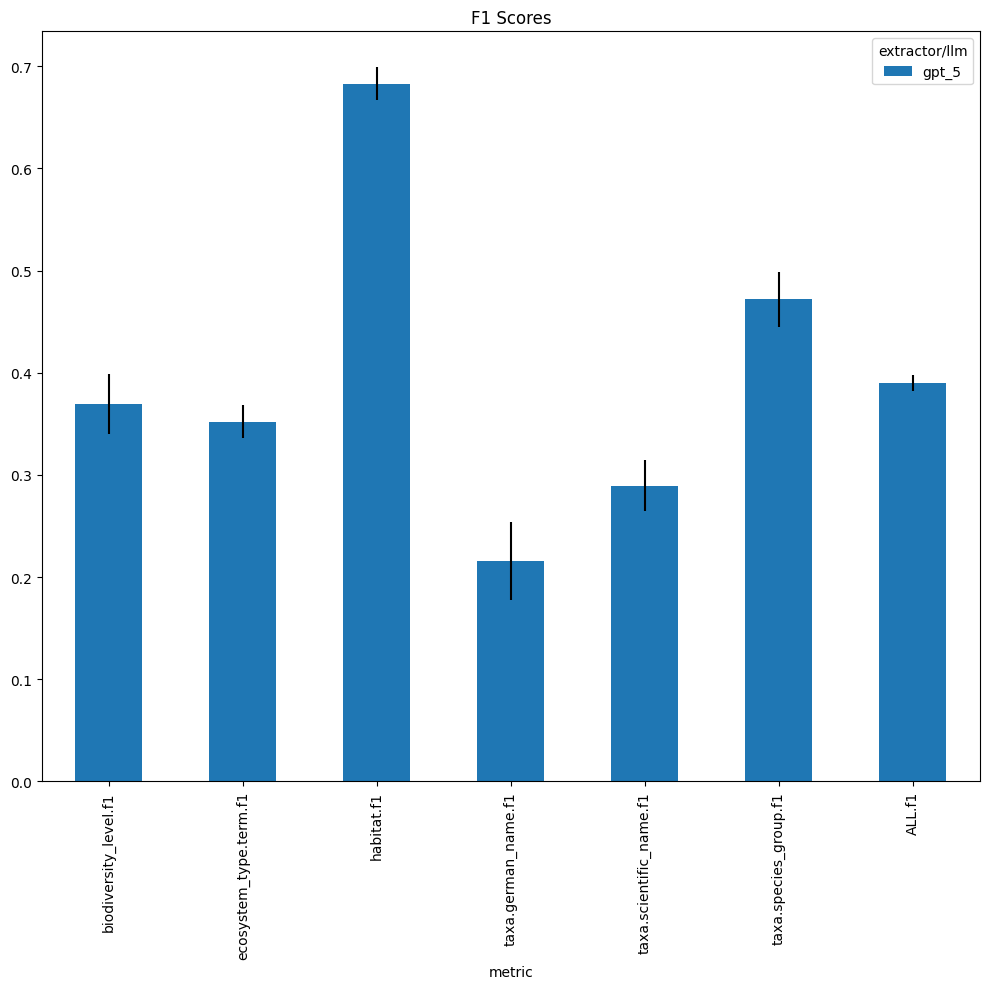

In [7]:
fig = plot(
    data=metrics_df,
    index_column=INDEX_COLUMNS,
    include_cols_regex=r"[^G]\.f1" if not is_comparison else "ALL.f1",
    title="F1 Scores",
    # enable to show interim dataframes
    # verbose=True,
    figsize=FIGSIZE,
    **PLOT_KWARGS,
)

In [8]:
# save metrics plot
file_name = FILE_NAME_PREFIX + ("comparison_" if is_comparison else "") + "metrics.svg"
fig.savefig(BASE_LOG_DIR / NAME / file_name)

In [9]:
if is_comparison:
    fig = plot(
        data=metrics_df,
        index_column=INDEX_COLUMNS,
        include_cols_regex=r"[^GL]\.f1",
        # enable to show interim dataframes
        # verbose=True,
        figsize=FIGSIZE,
        # shorten_labels=False,
        **PLOT_KWARGS,
    )
    file_name = FILE_NAME_PREFIX + ("comparison_" if is_comparison else "") + "metrics_detail.svg"
    fig.savefig(BASE_LOG_DIR / NAME / file_name)

# Support

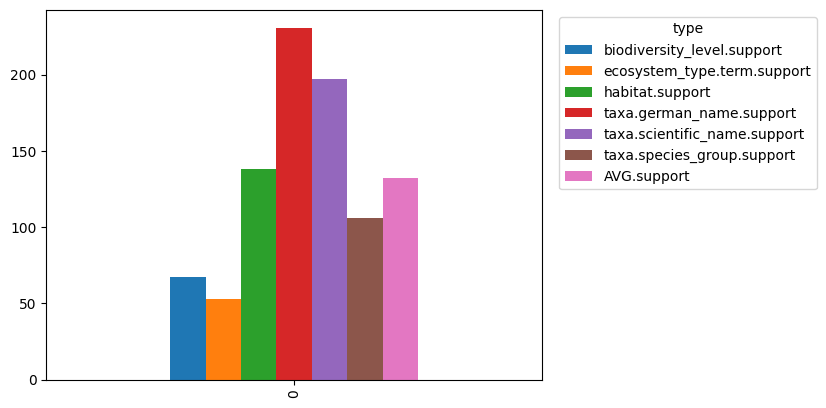

In [10]:
cols_to_plot = [col for col in metrics_df.columns if "support" in col and "ALL" not in col]
# get the first row, but as dataframe so that we have color-coded bars and a legend
ax = metrics_df[cols_to_plot].iloc[0:1].plot(kind="bar")
ax.legend(title="type", bbox_to_anchor=(1.02, 1), loc="upper left")
# ax.figure.tight_layout()

# Errors

In [11]:
# we analyse error counts, so aggregate by summing them up
errors_df_avg = mixed_group_by(errors_df, by=INDEX_COLUMNS)
errors_df_avg

,prediction.job_return_value.time_pdf_conversion,prediction.job_return_value.time_extraction,no_error,with_error,ValueError,ReasoningExtractionError,JSONDecodeError,MissingResponseContentError,prediction.job_return_value.output_file_absolute,prediction.job_return_value.commit_hash,prediction.job_return_value.branch,prediction.job_return_value.is_dirty,prediction.overrides.name,prediction.overrides.experiment/predict,prediction.overrides.pdf_directory,prediction.overrides.extractor.return_reasoning,prediction.overrides.seed,overrides.dataset.predictions.log,overrides.name,overrides.experiment/evaluate,overrides.prediction_logs
prediction.overrides.extractor/llm,,,,,,,,,,,,,,,,,,,,,
gpt_5,0.014566,6884.810342,86.666667,13.333333,8.0,1.0,2.333333,2.0,"[/netscratch/binder/projects/kibad-llm/predictions/88_faktencheck_core_gpt5_baseline/2026-01-31_16-22-31/2026-01-31_16-22-31_957220/predictions.jsonl, /netscratch/binder/projects/kibad-llm/predictions/88_faktencheck_core_gpt5_baseline/2026-01-31_16-22-31/2026-01-31_18-38-49_281164/predictions.jsonl, /netscratch/binder/projects/kibad-llm/predictions/88_faktencheck_core_gpt5_baseline/2026-01-31_...","[dd1413a20fc344dbbb95a79b18a4ab5c625cd3c5, dd1413a20fc344dbbb95a79b18a4ab5c625cd3c5, dd1413a20fc344dbbb95a79b18a4ab5c625cd3c5]","[run-script/parametrize-num-gpus, run-script/parametrize-num-gpus, run-script/parametrize-num-gpus]","[False, False, False]","[88_faktencheck_core_gpt5_baseline, 88_faktencheck_core_gpt5_baseline, 88_faktencheck_core_gpt5_baseline]","[faktencheck_core_fields_schema_with_evidence, faktencheck_core_fields_schema_with_evidence, faktencheck_core_fields_schema_with_evidence]","[/ds/text/kiba-d/dev-set-100, /ds/text/kiba-d/dev-set-100, /ds/text/kiba-d/dev-set-100]","[True, True, True]","[42, 1337, 7331]","[logs/88_faktencheck_core_gpt5_baseline/predict/multiruns/2026-01-31_16-22-31/0, logs/88_faktencheck_core_gpt5_baseline/predict/multiruns/2026-01-31_16-22-31/1, logs/88_faktencheck_core_gpt5_baseline/predict/multiruns/2026-01-31_16-22-31/2]","[88_faktencheck_core_gpt5_baseline, 88_faktencheck_core_gpt5_baseline, 88_faktencheck_core_gpt5_baseline]","[prediction_errors, prediction_errors, prediction_errors]","[logs/88_faktencheck_core_gpt5_baseline/predict, logs/88_faktencheck_core_gpt5_baseline/predict, logs/88_faktencheck_core_gpt5_baseline/predict]"


INFO:__main__:use columns (name=metric): ['no_error', 'with_error', 'prediction.overrides.extractor/llm']


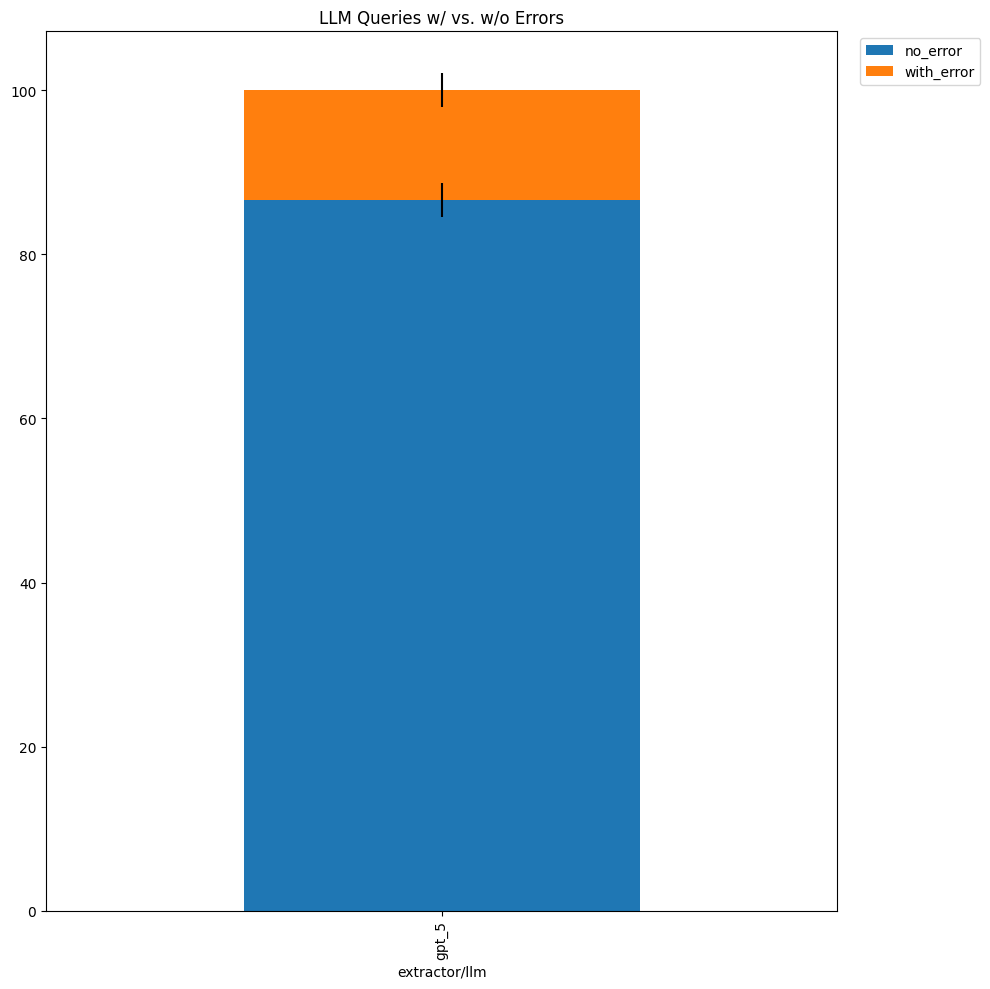

In [12]:
if not is_comparison:
    # show with stddev
    PLOT_ERRORS_SINGLE_KWARGS = {
        "xgroup": "metric",
        "stacked": True,
        # put legend outside at the right
        "legend_kwargs": dict(bbox_to_anchor=(1.02, 1), loc="upper left"),
    }
    fig = plot(
        errors_df,
        index_column=INDEX_COLUMNS,
        include_cols_regex=r"error",
        **PLOT_ERRORS_SINGLE_KWARGS,
        # use PLOT_KWARGS instead of PLOT_ERRORS_SINGLE_KWARGS for A/B comparisons
        # **PLOT_KWARGS,
        figsize=FIGSIZE,
        title="LLM Queries w/ vs. w/o Errors",
    )
else:
    fig = plot(
        errors_df,
        index_column=INDEX_COLUMNS,
        include_cols_regex=r"with_error",
        **PLOT_KWARGS,
        figsize=FIGSIZE,
        title="LLM Queries with Errors",
    )

In [13]:
# save the errors plot
file_name = FILE_NAME_PREFIX + ("comparison_" if is_comparison else "") + "errors.svg"
fig.savefig(BASE_LOG_DIR / NAME / file_name)

INFO:__main__:use columns (name=metric): ['ValueError', 'ReasoningExtractionError', 'JSONDecodeError', 'MissingResponseContentError', 'prediction.overrides.extractor/llm']


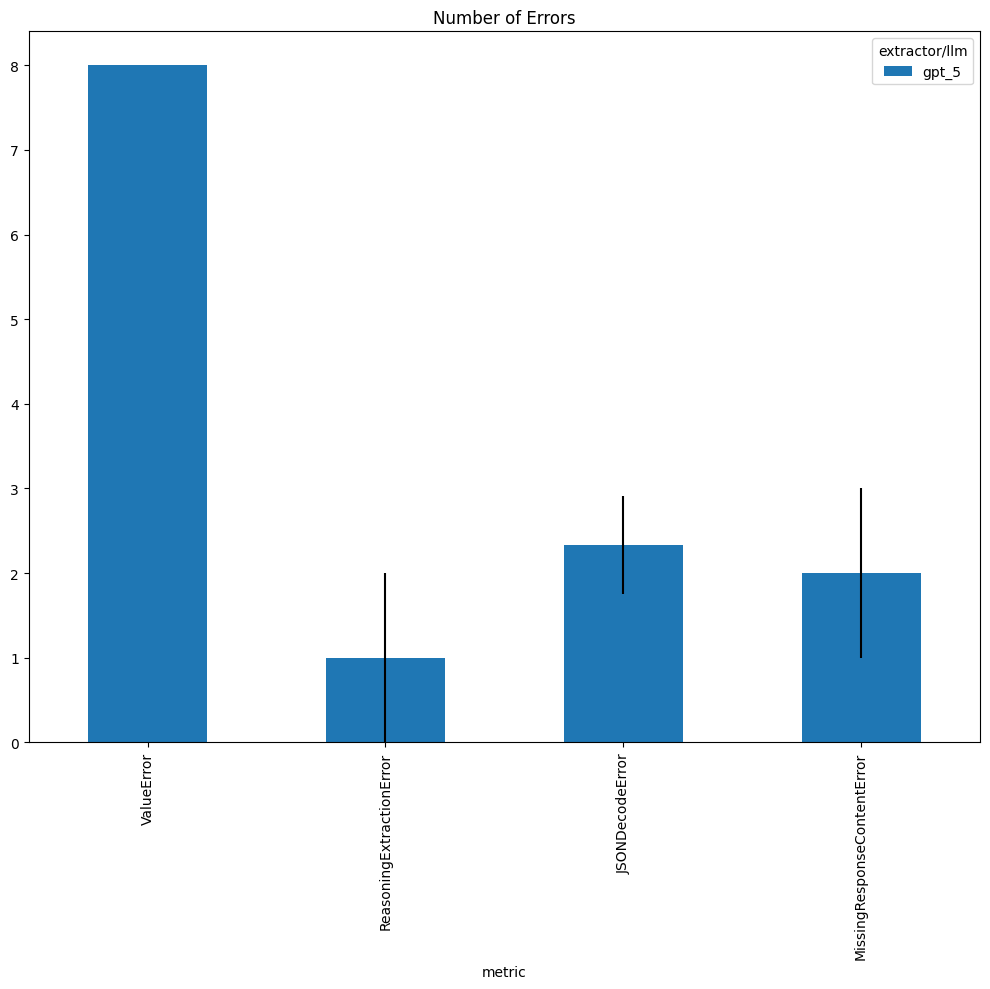

In [14]:
fig = plot(
    errors_df,
    index_column=INDEX_COLUMNS,
    include_cols_regex=r"Error",
    **PLOT_KWARGS,
    figsize=FIGSIZE,
    title="Number of Errors" if not is_comparison else None,
)

In [15]:
# save the errors plot
file_name = FILE_NAME_PREFIX + ("comparison_" if is_comparison else "") + "errors_detail.svg"
fig.savefig(BASE_LOG_DIR / NAME / file_name)